In [1]:
from tabnanny import verbose
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os
import cv2
from imutils import paths
import numpy as np
import skimage.io as io
from scipy.interpolate import splprep, splev
import matplotlib.pyplot as plt

2022-10-07 17:17:07.700007: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1


In [2]:
def loadData(dataPaths):
    dataPaths = list(paths.list_images(dataPath))
    return dataPaths

In [19]:
def cleanImage(orig_im):

    im = orig_im.copy()

    h, w = im.shape[0], im.shape[1]

    # Seed points for floodFill (use two points at each corner for improving robustness)
    seedPoints = ((0, 0), (10, 10), (w-1, 0), (w-1, 10), (0, h-1), (10, h-1), (w-1, h-1), (w-10, h-10))
    
    # Fill background with black color
    for seed in seedPoints:
        cv2.floodFill(im, None, seedPoint=seed, newVal=(0, 0, 0), loDiff=(0, 0, 0), upDiff=(18, 18, 18))
    
    # Use "close" morphological operation
    im = cv2.morphologyEx(im, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10,10)));
    
    #Convert to Grayscale, and then to binary image.
    gray = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
    ret, thresh_gray = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)
    
    #Find contours
    contours, _ = cv2.findContours(thresh_gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    c = max(contours, key=cv2.contourArea) # Get the largest contour

    # Smooth contour
    # https://agniva.me/scipy/2016/10/25/contour-smoothing.html
    x,y = c.T
    x = x.tolist()[0]
    y = y.tolist()[0]
    tck, u = splprep([x,y], u=None, s=1.0, per=1)
    u_new = np.linspace(u.min(), u.max(), 20)
    x_new, y_new = splev(u_new, tck, der=0)
    res_array = [[[int(i[0]), int(i[1])]] for i in zip(x_new,y_new)]
    smoothened = np.asarray(res_array, dtype=np.int32)
    
    # To view Image with detected contour
    test_im = orig_im.copy()
    cv2.drawContours(test_im, [smoothened], 0, (0, 255, 0), 1)

    # Build a mask
    mask = np.zeros_like(thresh_gray)
    cv2.drawContours(mask, [smoothened], -1, 255, -1)

    # Apply mask
    res = np.zeros_like(orig_im)
    res[(mask > 0)] = orig_im[(mask > 0)]
    
    return res


In [20]:
def cropImage(img):
    grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _,thresholded = cv2.threshold(grayscale, 0, 255, cv2.THRESH_OTSU)
    #cv2.imwrite("otsu.png", thresholded)
    bbox = cv2.boundingRect(thresholded)
    x, y, w, h = bbox
    #print(bbox)
    croppedImg = img[y:y+h, x:x+w]
    return croppedImg

In [21]:
def resizeImage(img, size=(28,28)):

    h, w = img.shape[:2]
    c = img.shape[2] if len(img.shape)>2 else 1

    if h == w: 
        return cv2.resize(img, size, cv2.INTER_AREA)

    dif = h if h > w else w

    interpolation = cv2.INTER_AREA if dif > (size[0]+size[1])//2 else cv2.INTER_CUBIC

    x_pos = (dif - w)//2
    y_pos = (dif - h)//2

    if len(img.shape) == 2:
        mask = np.zeros((dif, dif), dtype=img.dtype)
        mask[y_pos:y_pos+h, x_pos:x_pos+w] = img[:h, :w]
    else:
        mask = np.zeros((dif, dif, c), dtype=img.dtype)
        mask[y_pos:y_pos+h, x_pos:x_pos+w, :] = img[:h, :w, :]

    return cv2.resize(mask, size, interpolation)

In [45]:

def loadImage(dataPath):
    # Load data path
    dataPaths = list(paths.list_images(dataPath))
    # Create lists
    data = []
    labels = []
    # Read image and store in Data and masks lists
    for imagePath in dataPaths:
        image = cv2.imread(imagePath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = imagePath.split(os.path.sep)[-2]
        
        image = cleanImage2(image)
        image = cropImage(image)
        image = resizeImage(image, (224, 224))
        #print(image.shape)
        
        data.append(image)
        labels.append(label)
    #convert data and image to numpy array objects
    data = np.array(data) / 255.0
    labels = np.array(labels)
    # return data and mask pair
    return (data, labels, dataPaths)



In [46]:
data, labels, dataPaths = loadImage(r'/home/bishal/Research/Allergic-Rhinitis/Dataset/rotate')

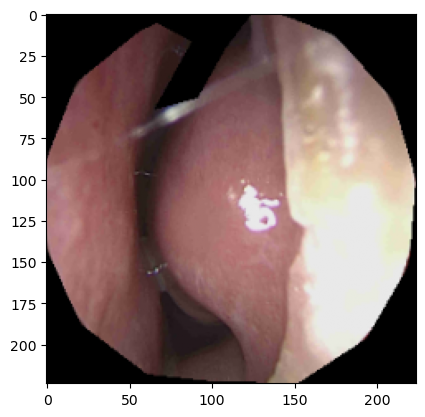

In [256]:
plt.imshow(data[67])

In [170]:
def prepareGenerator(data, labels, genArgs):
    # create image data augmentation generator
    datagen = ImageDataGenerator(**genArgs)
    iterGen = datagen.flow(data, labels, batch_size=1, seed=1)
    # return iterator
    return (iterGen)

In [171]:
def startGenerator(iterGen, reqImages=10, 
                   savePath = r'/home/bishal/Research/Allergic-Rhinitis/Dataset/rotateAug'):
    for i in range(reqImages):
        genData, genLabel = iterGen.next()
        genData = genData[0] * 255
        genData = genData.astype(np.uint8)
        if genLabel[0]=='0':
            io.imsave(os.path.join(savePath+"/0","%d_.png"%i), genData)
        elif genLabel[0]=='1':
            io.imsave(os.path.join(savePath+"/1","%d_.png"%i), genData)
        elif genLabel[0]=='2':
            io.imsave(os.path.join(savePath+"/2","%d_.png"%i), genData)
        print('Generating Images: ', i+1, end="\r")
    print("")

In [221]:
genArgs = dict(rotation_range=3,
                    width_shift_range=0.05,
                    height_shift_range=0.05,
                    zoom_range=0.05,
                    fill_mode='constant')

In [222]:
gen = prepareGenerator(data, labels, genArgs)

In [223]:
startGenerator(gen, 100)

Generating Images:  100


In [ ]:
if __name__ == "__main__":
    dataGenArgs = dict(rotation_range=5,
                    width_shift_range=0.05,
                    height_shift_range=0.05,
                    shear_range=0.05,
                    zoom_range=0.05,
                    horizontal_flip=True,
                    vertical_flip=True,
                    fill_mode='reflect')

    augmentData(dataPath=r'/home/bluesaiyancodes/Documents/imageSegmentation/data',
                savePath=r'/home/bluesaiyancodes/Documents/imageSegmentation/dataSegmentated',
                reqImages=1000,
                genArgs = dataGenArgs) 

In [175]:
len(data)

90

In [47]:
savePath = r'/home/bishal/Research/Allergic-Rhinitis/Dataset/cleaned'
for i in range(len(data)):
    data_ = data[i] * 255.0
    data_ = data_.astype(np.uint8)
    io.imsave(os.path.join(savePath,"%d_.png"%i), data_)

In [31]:
dataPaths[55]

'/home/bishal/Research/Allergic-Rhinitis/Dataset/rotate/dataset2/1/19_1_00002_right.tif'

In [178]:
savePath2 = r'/home/bishal/Research/Allergic-Rhinitis/Dataset/untouched'
dataPaths = list(paths.list_images(r'/home/bishal/Research/Allergic-Rhinitis/Dataset/rotate'))
i = 0
for imagePath in dataPaths:
        image = cv2.imread(imagePath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image.astype(np.uint8)
        io.imsave(os.path.join(savePath2,"%d_.png"%i), image)
        i+=1

In [ ]:
img = cv2.imread(dataPaths[55], cv2.IMREAD_COLOR)

# Convert to grayscale and blur
image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# Input to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Simple binary threshold
_, gray = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)

# Find contours
cnts, _ = cv2.findContours(gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

# Generate mask
mask = np.ones(gray.shape)
mask = cv2.drawContours(mask, cnts, -1, 0, cv2.FILLED)

# Generate output
output = image.copy()
output[mask.astype(np.bool), :] = 0

plt.imshow(output)
#cv2.imwrite("images/input.png", image)
#cv2.imwrite("images/mask.png", np.uint8(255 * mask))
#cv2.imwrite("images/output.png", output)

In [ ]:
from scipy.interpolate import splprep, splev

In [84]:
path = dataPaths[56]
orig_im = cv2.imread(path,cv2.IMREAD_COLOR)
orig_im = cv2.cvtColor(orig_im, cv2.COLOR_BGR2RGB)


im = orig_im.copy()

h, w = im.shape[0], im.shape[1]

# Seed points for floodFill (use two points at each corner for improving robustness)
seedPoints = ((0, 0), (10, 10), (w-1, 0), (w-1, 10), (0, h-1), (10, h-1), (w-1, h-1), (w-10, h-10))

# Fill background with black color
for seed in seedPoints:
    cv2.floodFill(im, None, seedPoint=seed, newVal=(0, 0, 0), loDiff=(0, 0, 0), upDiff=(5, 5, 5))

# Use "close" morphological operation
im = cv2.morphologyEx(im, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10,10)));

#Convert to Grayscale, and then to binary image.
gray = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
ret, thresh_gray = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)

#Find contours
contours, _ = cv2.findContours(thresh_gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
c = max(contours, key=cv2.contourArea) # Get the largest contour

# Smooth contour
# https://agniva.me/scipy/2016/10/25/contour-smoothing.html
x,y = c.T
x = x.tolist()[0]
y = y.tolist()[0]
tck, u = splprep([x,y], u=None, s=1.0, per=1)
u_new = np.linspace(u.min(), u.max(), 20)
x_new, y_new = splev(u_new, tck, der=0)
res_array = [[[int(i[0]), int(i[1])]] for i in zip(x_new,y_new)]
smoothened = np.asarray(res_array, dtype=np.int32)

# For testing
test_im = orig_im.copy()
cv2.drawContours(test_im, [smoothened], 0, (0, 255, 0), 1)

# Build a mask
mask = np.zeros_like(thresh_gray)
cv2.drawContours(mask, [smoothened], -1, 255, -1)

# Apply mask
res = np.zeros_like(orig_im)
res[(mask > 0)] = orig_im[(mask > 0)]

'''cv2.imshow('test_im', test_im)
cv2.imshow('res', res)
cv2.imshow('mask', mask)
cv2.waitKey(0)
cv2.destroyAllWindows()'''

"cv2.imshow('test_im', test_im)\ncv2.imshow('res', res)\ncv2.imshow('mask', mask)\ncv2.waitKey(0)\ncv2.destroyAllWindows()"

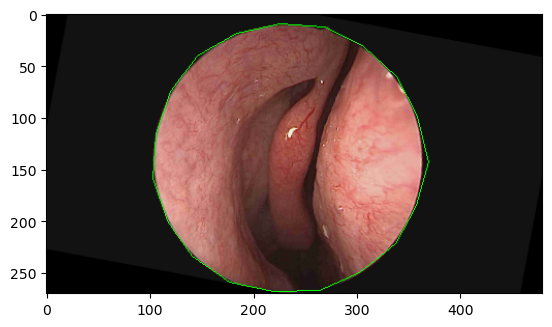

In [85]:
# Show images for testing
plt.imshow(test_im)


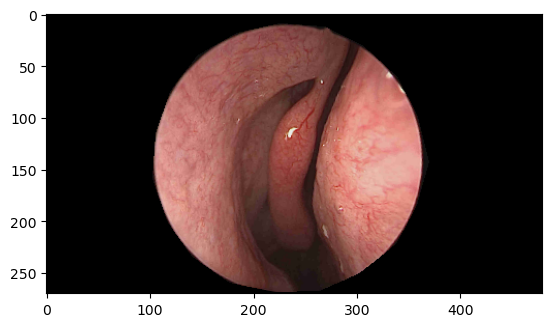

In [79]:
plt.imshow(res)

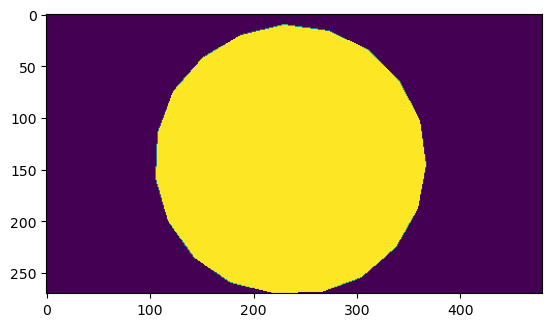

In [29]:

plt.imshow(mask)

In [40]:
def cleanImage2(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _ ,thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    
    circles = cv2.HoughCircles(thresh, cv2.HOUGH_GRADIENT, 1, 300, param1 = 250, param2 = 10, minRadius = 100, maxRadius = 1000)
    
    x, y, r = list(map(int, circles[0][0]))

    mask = np.zeros_like(img)
    mask = cv2.circle(mask, (x,y), r, (255,255,255), -1)
    # Apply mask
    res = np.zeros_like(img)
    res[(mask > 0)] = img[(mask > 0)]
    return res

"cv2.imwrite('shapes_inverted_mask.jpg', mask_inv)\ncv2.imwrite('shapes_masked.jpg', image_masked)\ncv2.imwrite('shapes_bckgrnd_masked.jpg', bckgnd_masked )\ncv2.imwrite('shapes_result.jpg', result)\n\ncv2.imshow('mask', mask)\ncv2.imshow('image_masked', image_masked)\ncv2.imshow('bckgrnd_masked', bckgnd_masked)\ncv2.imshow('result', result)\ncv2.waitKey(0)\ncv2.destroyAllWindows()"

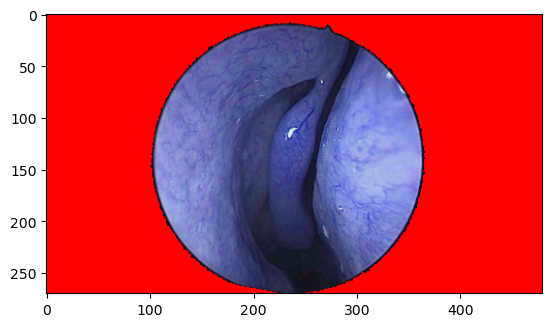

In [55]:
path = dataPaths[56]# Read image
path = dataPaths[56]
img = cv2.imread(path)
hh, ww = img.shape[:2]

# threshold on black
# Define lower and uppper limits of what we call "white-ish"
lower = np.arrpath = dataPaths[56]ay([0, 0, 0])
upper = np.array([20, 20, 20])

# Create mask to only select black
thresh = cv2.inRange(img, lower, upper)

# invert mask so shapes are white on black background
thresh_inv = 255 - thresh

# get the largest contour
contours = cv2.findContours(thresh_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = contours[0] if len(contours) == 2 else contours[1]
big_contour = max(contours, key=cv2.contourArea)

# draw white contour on black background as mask
mask = np.zeros((hh,ww), dtype=np.uint8)
cv2.drawContours(mask, [big_contour], 0, (255,255,255), cv2.FILLED)

# invert mask so shapes are white on black background
mask_inv = 255 - mask

# create new (blue) background
bckgnd = np.full_like(img, (255,0,0))

# apply mask to image
image_masked = cv2.bitwise_and(img, img, mask=mask)

# apply inverse mask to background
bckgnd_masked = cv2.bitwise_and(bckgnd, bckgnd, mask=mask_inv)

# add together
result = cv2.add(image_masked, bckgnd_masked)

plt.imshow(result)
# save results
'''cv2.imwrite('shapes_inverted_mask.jpg', mask_inv)
cv2.imwrite('shapes_masked.jpg', image_masked)
cv2.imwrite('shapes_bckgrnd_masked.jpg', bckgnd_masked )
cv2.imwrite('shapes_result.jpg', result)

cv2.imshow('mask', mask)
cv2.imshow('image_masked', image_masked)
cv2.imshow('bckgrnd_masked', bckgnd_masked)
cv2.imshow('result', result)
cv2.waitKey(0)
cv2.destroyAllWindows()'''

In [13]:
def cleanImage(image):
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            pixel = image[i][j]
            if sum(pixel)<=55:
                image[i][j] = [0, 0, 0]
    return image

def cropImage(img):
    grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _,thresholded = cv2.threshold(grayscale, 0, 255, cv2.THRESH_OTSU)
    #cv2.imwrite("otsu.png", thresholded)
    bbox = cv2.boundingRect(thresholded)
    x, y, w, h = bbox
    #print(bbox)
    croppedImg = img[y:y+h, x:x+w]
    return croppedImg

In [14]:
def loadImages(path=r'C:\Users\cvpr\Documents\Bishal\Allergic Rhinitis\Dataset\rotate', plotType="all", 
                    classification="multiclass", colorMode = "RGB", cleanImageF=False,
                    crop = False, correctColor=False, contours=False, printImgDemo=False):
    print("[INFO]: Trying to Read the images from ", path)
    data = []
    labels = []
    #  Configure the Image Location            
    # 이미지 위치 구성하기
    imagePaths = list(paths.list_images(path))

    singleImagePrintLabel = []

        # Save meta information for future img manipulation


        # Shuffle the items in the image data paths
        #shuffle(self.imagePaths)
        
        
        # Formatting data and labels
    for imagePath in imagePaths:
            # Extract the class label from file name and append to labels
            # 파일 이름에서 클래스 레이블을 추출하고 레이블에 추가함
        label = imagePath.split(os.path.sep)[-2]

            # dividing labels based on multiclass or binary
        if classification=="binary":
            if label=="2":
                labels.append("1")
            else:
                labels.append(label)
        else:
            labels.append(label)
        

            # Load the image, swap color channels, and resize it to be a fixed 224x224 pixels while ignoring the aspect ratio
            # 이미지를 로드하고, 컬러 채널을 스왑하고, 가로 세로 비율을 무시하고 고정 224x224 픽셀로 크기를 조정함
        if colorMode=="LAB":
            image = cv2.imread(imagePath)
            image = image.astype("float32")
            image = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)
        else:
            image = cv2.imread(imagePath)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # To clean the image that is remove the black noise from the picture
        if cleanImageF:
            image = cleanImage(image)

        # To crop the image to the subject size
        if crop:
            image = cropImage(image)
            # Cropping requires re-size due to irregularity in the  dim of image cropping
            image = cv2.resize(image, (224,224))


        

        # Append to data
        # 데이터에 추가
        data.append(image)
        # Adding to metadata
        
    data = np.array(data) / 255.0
    labels = np.array(labels)
        
    print("Images found :", len(data))
    return (data, labels)

In [16]:
data, labels = loadImages(path=r'/home/bishal/Research/Allergic-Rhinitis/Dataset/rotate', plotType="all", 
                    classification="multiclass", colorMode = "RGB", cleanImageF=True,
                    crop = True, correctColor=False, contours=False, printImgDemo=False)

[INFO]: Trying to Read the images from  /home/bishal/Research/Allergic-Rhinitis/Dataset/rotate
Images found : 90


In [283]:
data[1].shape

(270, 480, 3)

In [48]:
path = r'/home/bishal/Research/Allergic-Rhinitis/Dataset/cleaned/'
savePath = r'/home/bishal/Research/Allergic-Rhinitis/Dataset/cleanedGray/'
imagePaths = list(paths.list_images(path))
i=0
for imagePath in imagePaths:
    imf = cv2.imread(imagePath)
    imf = imf*255
    plt.imsave(os.path.join(savePath,"%d_.png"%i), imf)
    i+=1
    #plt.imshow(imf)
    #cv2.imwrite(os.path.join(savePath,"%d_.png"%i), data_)
    #/io.imsave(os.path.join(savePath,"%d_.png"%i), data_, cmap = plt.cm.gray)
    #plt.savefig(os.path.join(savePath,"%d_.png"%i))

In [322]:
len(imagePaths)

90

In [ ]:
savePath = r'/home/bishal/Research/Allergic-Rhinitis/Dataset/tmp'
for i in range(len(data)):
    data_ = data[i] * 255
    data_ = data_.astype(np.uint8)
    io.imsave(os.path.join(savePath,"%d_.png"%i), data_)